In [1]:
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
from tqdm import tqdm
import sys
import emcee
import corner
sys.path.append("..")

In [2]:
%load_ext autoreload
%autoreload 2
import strings

In [3]:
planckdata = np.loadtxt('../data/planck_TT.txt', skiprows=1)
planckL = planckdata[:, 0]
planckww = planckdata[:, 1]
planckww_err = planckdata[:, 2] 
planckWW = planckww * 1e7 / (2 * np.pi)
planckWW_err = planckww_err * 1e7 / (2 * np.pi)

In [11]:
class Likelihood:
    def __init__(self, P=None, G_mu=None, N_k=30, lmax=500, data_l=None, data=None, std=None):
        if P is None:
            Pconst = False
        else:
            Pconst = True
            assert G_mu is not None, "G_mu must be provided if P is constant"
        self.Pconst = Pconst
        self.P = P
        self.G_mu = G_mu
        self.N_k = N_k
        self.lmax = lmax
        if Pconst:
            self.l, self.CL = strings.compute_cls(G_mu=G_mu, P=P, N_k=N_k,custom_l_arr=data_l)
        else:
            self.l, self.CL = None, None
        self.data_l = data_l
        self.data = data
        self.std = std

    def theory(self, G_mu, P=None):
        if self.Pconst:
            diff = self.G_mu/G_mu
            l,cl = self.l,diff**2 * self.CL
        else:
            assert P is not None, "P must be provided for non-constant P"
            l, cl = strings.compute_cls(G_mu=G_mu, P=P, N_k=self.N_k,custom_l_arr=self.data_l,progress_bar=False)
        
        return l, cl*1e7 / (2 * np.pi)
    
    def chi2(self, theta):
        if self.Pconst:
            G_mu = theta
            l, cl = self.theory(G_mu)
        else:
            G_mu, P = theta
            l, cl = self.theory(G_mu, P)

        diff = (self.data- cl)
        plt.errorbar(self.data_l, self.data, yerr=self.std, fmt='o', label='Data')
        plt.plot(l, cl, label='Theory')
        plt.semilogx()
        std = self.std
        ratio = diff / std
        ratio[np.isnan(ratio)] = 0
        ratio[np.isinf(ratio)] = 0
        chi2_val = np.sum(ratio**2)
        return chi2_val
    
    def log_prior(self,theta):
        if self.Pconst:
            G_mu = theta
            if 0 < G_mu < 1e-3:
                return 0.0
            else:
                return -np.inf
        else:
            G_mu, P = theta
            if 0 < G_mu < 1e-3 and 0.0 < P < 1:
                return 0.0
            return -np.inf
        
    def log_likelihood(self, theta):
        chi2_val = self.chi2(theta)
        return -0.5 * chi2_val
    

    def run_mcmc(self, nwalkers=100, nsteps=5000, initial=None):
        ndim = 1 if self.Pconst else 2
        if initial is None:
            if self.Pconst:
                initial = np.random.uniform(8e-4, 1e-3, size=(nwalkers, ndim))
            else:
                initial = np.random.uniform([1e-4, 0.1], [1e-3, 10.0], size=(nwalkers, ndim))

        sampler = emcee.EnsembleSampler(nwalkers, ndim, self.log_likelihood, 
                                        a=self.log_prior)
        sampler.run_mcmc(initial, nsteps,progress=True)
        return sampler

In [12]:
lh_Pconst = Likelihood(P=1, G_mu=7e-4, N_k=30,  data_l=planckL, data=planckWW, std=planckWW_err)

Computing C_l:  21%|██▏       | 3/14 [00:00<00:00, 26.55ℓ/s]/Users/antoidicherianlonappan/Workspace/cosmic_strings/notebooks/../strings.py:71: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  inner, _ = quad(inner_integrand,
Computing C_l: 100%|██████████| 14/14 [00:00<00:00, 62.06ℓ/s]


31.962680066756878

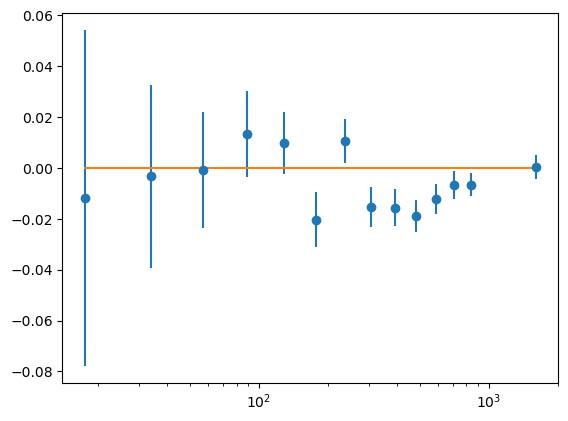

In [15]:
lh_Pconst.chi2(8.9)

In [8]:
sampler = lh_Pconst.run_mcmc(nwalkers=32, nsteps=1000)
samples = sampler.get_chain(flat=True,discard=100)

100%|██████████| 1000/1000 [00:00<00:00, 2807.45it/s]


In [10]:
samples

array([[-4.18630086e+007],
       [ 3.86757039e+005],
       [ 5.20882484e+007],
       ...,
       [-3.00747230e+118],
       [ 1.85887580e+118],
       [-2.19139252e+118]])

In [7]:
lh = Likelihood( N_k=30,  data_l=planckL, data=planckWW, std=planckWW_err)

In [ ]:
sample = lh.run_mcmc(nwalkers=32, nsteps=1000)

/Users/antoidicherianlonappan/Workspace/cosmic_strings/notebooks/../strings.py:71: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  inner, _ = quad(inner_integrand,
  1%|          | 6/1000 [00:56<2:47:11, 10.09s/it]

In [35]:
samples = sample.get_chain(flat=True)

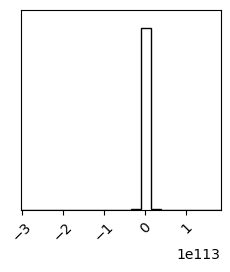

In [36]:
fig = corner.corner(samples)